# LLM Alignment

## Agenda
1. Introduction: Why Align Language Models?
2. Instruction Tuning
3. Reinforcement Learning from Human Feedback (RLHF)
4. Direct Preference Optimization (DPO)
5. Reasoning in Large Language Models
6. Group Relative Policy Optimization (GRPO)

# Introduction: Why Align Language Models?

Large Language Models (LLMs) are trained to predict text, but without careful alignment, their objectives can conflict with human intentions. An *unaligned* LLM may generate harmful or nonsensical outputs even when that’s not what the user wants. For example, the base GPT-3 model often produced irrelevant or toxic completions, whereas an aligned version (InstructGPT) was found to be significantly **less toxic, less prone to factual errors, and more responsive to instructions** ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=To%20measure%20the%20safety%20of,C)). Alignment aims to steer LLMs toward helpful, truthful, and non-harmful behavior consistent with human preferences.

Misalignment can manifest in various ways:

- **Toxic or biased outputs:** Models trained on internet text might emit offensive language or stereotypes if prompted, since they lack an internal notion of “should not say that” without alignment ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=Instruction,stereotypes%2C%20and%20produce%20toxic%20language)).
- **Hallucinations and falsehoods:** Without alignment toward truthfulness, LLMs may confidently produce incorrect information or “imitative falsehoods” ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=To%20measure%20the%20safety%20of,C)).
- **Ignoring user intent:** A base model might respond with a continuation unrelated to a user’s request (since it wasn’t trained explicitly to *follow instructions*). This fails the helpfulness criterion.
- **Overly literal or dangerous compliance:** If not aligned with human values, a model might comply with harmful requests (e.g. instructions to create a weapon) or follow instructions too literally without common-sense safety checks.

In short, LLM alignment is necessary to ensure AI systems do what *we* want them to do, not just what their raw training optimizes. As models become more powerful, alignment becomes even more critical to prevent unintended consequences. A famous analogy is the "paperclip maximizer" thought experiment – an AI optimizing an objective (like making paperclips) without alignment might pursue it to absurd, harmful extremes. While current LLMs aren’t autonomous agents, even as assistants they require alignment so that their vast knowledge and capabilities are applied usefully and safely.

**Goals of LLM alignment** often include:
- *Helpfulness*: Provide relevant, correct, and useful answers following the user’s instructions.
- *Harmlessness*: Avoid causing harm – e.g. refuse requests for illicit instructions, avoid hate speech or harassment.
- *Honesty*: Tell the truth as much as possible and acknowledge uncertainty or mistakes (sometimes grouped with helpfulness, as in “helpful and truthful”).
- *Understandability*: Preferably, aligned models can explain their reasoning or decisions when asked, increasing transparency.

Modern alignment techniques add additional training steps after the initial pre-training. Pre-trained LLMs (trained on web text) have *general knowledge* and linguistic ability, but **alignment steps fine-tune these models to align with human *preferences* and *instructions*** ([Direct Preference Optimization Explained In-depth](https://www.tylerromero.com/posts/2024-04-dpo/#:~:text=3.%20Finally%2C%20we%20fine,the%20relative%20simplicity%20of%20the)). Alignment can be seen as shaping the model’s behavior distribution without significantly damaging its base capabilities.

In this lecture, we will cover the key methods for aligning LLMs:
1. **Instruction Tuning** – Supervised fine-tuning on instruction-response data (e.g. user prompts and desired answers) to teach models to follow human instructions.
2. **Reinforcement Learning from Human Feedback (RLHF)** – Using human preference judgments as a reward signal, often optimized via Proximal Policy Optimization (PPO).
3. **Direct Preference Optimization (DPO)** – A recent alternative to RLHF that directly optimizes the model on preference comparisons with a simpler loss (no reward model needed).
4. **Group Relative Policy Optimization (GRPO)** – A novel RL technique (introduced by *DeepSeek*) that improves efficiency by using group-wise comparisons instead of a separate value model.
5. **Other alignment approaches** – including Reinforcement Learning from AI Feedback (RLAIF), Self-Play Fine-Tuning (SPIN), and Constitutional AI – which offer additional ideas to reduce reliance on human labels or improve alignment.

Throughout, we will present the conceptual ideas, some mathematical formulations, and code snippets or pseudo-code to illustrate how these methods are implemented. Let’s start with the simplest approach: instruction tuning.

We usually use a special format with system/special tags wrapped around the text.
For example, LLAMA3 special tokens:
- <|begin_of_text|>: This is equivalent to the BOS token
- <|eot_id|>: This signifies the end of the message in a turn.
- <|start_header_id|>{role}<|end_header_id|>: These tokens enclose the role for a particular message. The possible roles can be: system, user, assistant.
- <|end_of_text|>: This is equivalent to the EOS token. On generating this token, Llama 3 will cease to generate more tokens.
A prompt can optionally contain a single system message, or multiple alternating user and assistant messages, but always ends with the last user message followed by the assistant header.

```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a helpful AI assistant for travel tips and recommendations<|eot_id|><|start_header_id|>user<|end_header_id|>

What is France's capital?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Bonjour! The capital of France is Paris!<|eot_id|><|start_header_id|>user<|end_header_id|>

What can I do there?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Paris, the City of Light, offers a romantic getaway with must-see attractions like the Eiffel Tower and Louvre Museum, romantic experiences like river cruises and charming neighborhoods, and delicious food and drink options, with helpful tips for making the most of your trip.<|eot_id|><|start_header_id|>user<|end_header_id|>

Give me a detailed list of the attractions I should visit, and time it takes in each one, to plan my trip accordingly.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

```

# Instruction Tuning (Supervised Fine-Tuning on Instructions)

One foundational alignment strategy is **instruction tuning**, which is simply supervised learning on a dataset of instructions and ideal model outputs. This aligns the model to *follow instructions* and produce helpful responses in a conversational format. Instruction tuning can correct a model’s tendency to ignore user prompts or to respond in an unhelpful way.

**What is Instruction Tuning?** It means we take a pre-trained LLM and fine-tune it on examples of the form: *Prompt (instruction) → High-quality completion*. The prompt might be a question or task description, and the completion is a demonstrated correct or helpful answer. By training on many such pairs, the LLM learns to generate appropriate outputs when given a new instruction.

This method was popularized by works like Google’s FLAN and OpenAI’s InstructGPT, and it can use either human-written instructions or instructions generated by a stronger model. 

For example, the **Stanford Alpaca** project created 52,000 example instruction-output pairs using OpenAI’s text-davinci-003, and then fine-tuned Meta’s LLaMA 7B model on this data ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=We%20introduce%20Alpaca%207B%2C%20a,our%20code%20release%20on%20GitHub)) ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=We%20are%20releasing%20our%20findings,small%20and%20easy%2Fcheap%20to%20reproduce)). The resulting **Alpaca model** (7B) behaved qualitatively similarly to text-davinci-003 on single-turn instructions ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=We%20introduce%20Alpaca%207B%2C%20a,our%20code%20release%20on%20GitHub)) – an impressive result given it was produced for under $600 of API calls. This demonstrated that even a relatively small LLM can learn the *instruction-following* behavior via supervised fine-tuning on high-quality demonstrations.

Some notable examples of instruction-tuned models:
- **FLAN-T5** (Google, 2021): T5 model fine-tuned on a mixture of many NLP tasks expressed as instructions, enabling strong zero-shot performance on unseen tasks by virtue of understanding instructions.
- **InstructGPT** (OpenAI, 2022): GPT-3 fine-tuned on human-written demonstrations and further refined with RLHF ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0)). This was a precursor to ChatGPT.
- **Alpaca** (Stanford, 2023): LLaMA 7B fine-tuned on 52K GPT-generated instructions ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=We%20introduce%20Alpaca%207B%2C%20a,our%20code%20release%20on%20GitHub)). Sparked a wave of open-source instruction-following models.
- **Vicuna** (2023 by LMSYS): LLaMA-based model fine-tuned on user-shared ChatGPT conversations (from ShareGPT). This used real interactions to shape a dialogue-style assistant.
- **Dolly 2.0** (Databricks, 2023): A model fine-tuned on a crowdsourced dataset of ~15k instruction-response pairs that were released under an open license.

The effect of instruction tuning is dramatic. A base model might complete a prompt literally or randomly, whereas an instruction-tuned model will address the user’s request directly and politely. It effectively teaches the model the *format* and *style* of a helpful assistant.


Other dataset examples:
- English Alpaca: [Alpaca](https://huggingface.co/datasets/tatsu-lab/alpaca)
- Ukrainian Alpaca: [UAlpaca](https://huggingface.co/datasets/PolyAgent/UAlpaca)
  
*In an actual environment, the base model might produce something incoherent or just continue the sentence, whereas the instruction-tuned model would likely produce a nice short poem.* This contrast highlights how much *behavior* can be encoded via supervised fine-tuning on instructions.

**Why instruction tuning helps:** It directly teaches the model the desired mapping from a user query to an answer. The language model already has the knowledge from pre-training; instruction tuning is about *packaging* that knowledge in a helpful way. Users found that instruct-tuned models are much more usable because you don’t have to prompt-engineer as much – the model is already biased toward interpreting your input as a request to fulfill, rather than just context to continue. OpenAI’s experiments showed that users strongly preferred the responses of an instruction-tuned model (with human feedback) over the original GPT-3’s responses ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20evaluate%20how%20well,following%C2%A0mode.%E2%80%9D)) ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=To%20measure%20the%20safety%20of,C)).

However, **instruction tuning alone is not perfect**. It relies on the quality of the instruction data. If the demonstrations have biases or gaps, the model will learn them. Also, an instruction-tuned model might still produce *undesirable outputs* if the instructions themselves lead to such outputs – e.g. if asked to produce harmful content, a purely instruction-tuned model might comply. Thus, more advanced alignment techniques (like RLHF) often follow instruction tuning to further refine the model’s behavior, especially for nuances like knowing *when to refuse* a request or how to balance competing principles.

In practice, instruction tuning is usually the **first step** in aligning a large model. For instance, **InstructGPT** and **Claude** (Anthropic) both start with a supervised fine-tuning phase on curated data (human-written or model-assisted demonstrations) ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0)) ([Constitutional AI: Harmlessness from AI Feedback \ Anthropic](https://www.anthropic.com/research/constitutional-ai-harmlessness-from-ai-feedback#:~:text=principles%2C%20and%20so%20we%20refer,assistant%20that%20engages%20with%20harmful)). This produces a reasonably aligned “SFT model.” The next step is to gather *preference data* and apply reinforcement learning to fine-tune the model further – that’s the RLHF stage.

Practical examples:
- [LLaMA3.1-8B Alpaca alignment](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-Alpaca.ipynb) by Unsloth team
- [Mistral7B Instruction tuning](https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/Mistral/Supervised_fine_tuning_(SFT)_of_an_LLM_using_Hugging_Face_tooling.ipynb#scrollTo=XrSQuIyu8Rt1) by Huggingface team

# Reinforcement Learning from Human Feedback (RLHF)


## Next Token prediction as a RL task
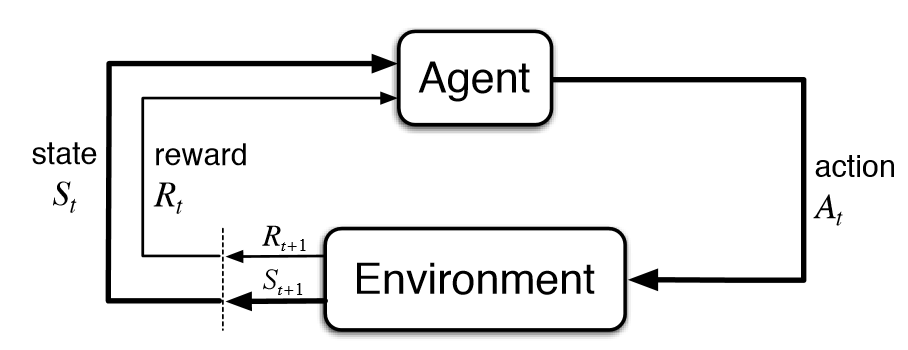


Given a sequence of tokens $s = (s_1, s_2, \ldots, s_T)$, the goal is to predict the next token $s_{T+1}$ based on the preceding context $s_{<T} = (s_1, s_2, \ldots, s_{T-1})$. In a Reinforcement Learning (RL) framework:

- **State ($s_t$):** The context comprising tokens $s_{<t}$.
- **Action ($a_t$):** The prediction of the next token $s_t$.
- **Reward ($r_t$):** A scalar feedback signal indicating the quality of the prediction, could be defined e.g. as:
  - $r_t = 1$ if $a_t = s_t$ (correct prediction).
  - $r_t = -1$ if $a_t \neq s_t$ (incorrect prediction).


## RLHF

While instruction tuning uses direct demonstrations of the desired behavior, **Reinforcement Learning from Human Feedback (RLHF)** takes it a step further: it uses human *preferences* as a signal to optimize the model’s behavior. Instead of just “Here’s a good response,” RLHF lets us say “Among these responses, humans prefer this one over that one” and use that information to adjust the model.

The RLHF pipeline was famously employed in OpenAI’s InstructGPT and ChatGPT models ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0)). The idea is to align the model with what humans *like* by *rewarding* outputs that humans rate as better.

**Typical RLHF process:**
1. **Supervised Fine-Tuning (SFT)** – (This we’ve done already) Start with a pre-trained model and fine-tune on human demonstrations of good behavior. This gives a decent initial policy $\pi_{\text{SFT}}$ that is used to bootstrap the next steps ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0)). ![](../../GuestLectures/images/rlhf_1.png)
2. **Collect Preference Data** – Humans are shown prompts and outputs from the current model (or multiple models) and asked to rank which output is better. Usually, this is done by showing two responses and asking which one the human prefers (A/B comparison). This yields a dataset of comparisons: (prompt, output A, output B, human-preferred output). ![](../../GuestLectures/images/review_form.png)
3. **Train a Reward Model (RM)** – Using the comparisons, train a separate model $R_\phi(x,y)$ that takes in a prompt and an output and predicts a *score* (reward) such that $R_\phi(x, y_{\text{preferred}}) > R_\phi(x, y_{\text{dispreferred}})$. In practice, this can be trained by logistic regression: the reward model is tuned so that $\sigma(R_\phi(x,y_A) - R_\phi(x,y_B))$ matches the probability that humans prefer $y_A$ over $y_B$ ([Constitutional AI: Harmlessness from AI Feedback \ Anthropic](https://www.anthropic.com/research/constitutional-ai-harmlessness-from-ai-feedback#:~:text=supervised%20phase%20we%20sample%20from,judged)). This step is effectively *learning a reward function* from human feedback. ![](../../GuestLectures/images/rlhf_2.png)
4. **Reinforcement Learning (policy optimization)** – Now we fine-tune the original model (the “policy” $\pi_\theta$) using the reward model as a guide. We generate outputs from the model, get a reward score from $R_\phi$, and update the model to increase that reward. However, we also have to ensure the model doesn’t drift too far from the original language distribution (to avoid nonsense or gaming the reward). In practice, this is done by adding a **KL-divergence penalty** or using the initial model as a reference. The common algorithm used is **Proximal Policy Optimization (PPO)** ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0)), which is a stable RL method for continuous action spaces (here, text generation). PPO can be applied by viewing the language model as a stochastic policy that we’re trying to optimize. ![](../../GuestLectures/images/rlhf_3.png)
Proximal Policy Optimization (PPO) is a reinforcement learning algorithm designed to train agents efficiently and stably by optimizing their policy functions. It achieves this by making controlled adjustments to the policy, preventing drastic changes that could destabilize learning.

**Updating Model Weights in PPO:**

1. **Collect Trajectories:** Run the current policy in the environment to gather a set of trajectories, which include states, actions, and rewards.

2. **Compute Advantages:** Calculate the advantage estimates for each action taken, which indicate how much better or worse an action was compared to the average. This part comprises two main components:
 -  **Actor (Policy Network):** This component determines the agent's actions based on the current policy.

 - **Critic (Value Function):** This component evaluates the actions taken by the actor by estimating the value function, which predicts the expected return (cumulative future rewards) from a given state.

- **Advantage Estimation:** The critic's value function helps compute the **advantage function**, which measures the relative benefit of an action taken in a particular state compared to the average. The advantage function is calculated as the difference between the observed return and the value function's estimate of the state's value:

  $$A(s, a) = Q(s, a) - V(s)$$

3. **Optimize the Objective Function:** Update the policy by maximizing the PPO objective function, which includes a clipped surrogate objective. This function uses the probability ratio between the current and previous policies, adjusted by the advantage estimates. The clipping mechanism ensures that policy updates are not too large, maintaining training stability.

4. **Multiple Optimization Epochs:** Perform several epochs of optimization on the collected data to refine the policy. This approach allows the policy to improve incrementally while adhering to the constraints imposed by the clipping mechanism.


**Results of RLHF:** When done correctly, RLHF can dramatically improve alignment. OpenAI reported that their InstructGPT (with RLHF) was preferred by users over the much larger GPT-3, and it produced outputs that were **more factual and less toxic** ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=To%20measure%20the%20safety%20of,C)). Essentially, the model learned to **not** say certain things and to **prioritize helpful answers** because the reward model captured those preferences. RLHF effectively “unlocks” behaviors that were possible but rare in the pre-trained model ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=One%20way%20of%20thinking%20about,and%20data%20relative%20to%20model%C2%A0pretraining)) – for example, politely refusing a request that violates policy was something the base model *could* do (it’s just words), but it wouldn’t without being trained to do so.

- **Strength**: it directly optimizes what we care about (human preference), producing highly preferred behavior.
- **Weakness**: it’s resource-intensive (many training steps, human data), and can be unstable without careful tuning.
- **When to use**: for high-stakes or high-quality assistant systems where you have human feedback data (or high-quality AI feedback, as we’ll discuss) and you need the last mile of alignment beyond supervised fine-tuning.

You can check some exact details behind different implementations:
- [The N Implementation Details of RLHF with PPO](https://huggingface.co/blog/the_n_implementation_details_of_rlhf_with_ppo)
- [The 37 Implementation Details of Proximal Policy Optimization](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/)
- [Mastering Proximal Policy Optimization (PPO) in Reinforcement Learning](https://medium.com/@felix.verstraete/mastering-proximal-policy-optimization-ppo-in-reinforcement-learning-230bbdb7e5e7)

# Direct Preference Optimization (DPO)

While RLHF has been successful, it introduces a lot of moving parts: a reward model, a policy training loop with PPO, etc. **Direct Preference Optimization (DPO)** is a newer method that aims to simplify this pipeline. The key idea, introduced by Rafailov et al. (2023), is that *we can optimize the language model on the preference data directly with a simple objective, without a separate reward model or reinforcement learning* ([[2305.18290] Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290#:~:text=solve%20the%20standard%20RLHF%20problem,simpler%20to%20implement%20and%20train)).

DPO’s motto is *“Your Language Model is Secretly a Reward Model.”* In other words, the language model itself can represent the reward function implicitly, if we set up the training right ([[2305.18290] Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290#:~:text=training,closed%20form%2C%20allowing%20us%20to)) ([[2305.18290] Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290#:~:text=resulting%20algorithm%2C%20which%20we%20call,simpler%20to%20implement%20and%20train)).

**How DPO works conceptually:**
- We start with the same kind of data as RLHF: pairs of outputs (or an output vs. another) with a preference label (which one is better).
- We also assume we have a reference model (often the SFT model, i.e., the model before preference tuning).
- Instead of training a separate reward network $R_\phi$, we derive a loss that directly adjusts the policy $\pi_\theta$ so that $\pi_\theta$ assigns higher probability to the preferred output $y^+$ and lower probability to the dispreferred $y^-$, relative to the reference policy.

Mathematically, under the hood, DPO derives from the same objective as RLHF (reward maximization with KL regularization). The authors show that the *optimal* policy has a particular form (as given above). They then basically *solve for $\pi_\theta$* that satisfies those optimality conditions. The result is an objective that looks like a **binary logistic regression** on the preference data:

$$
L_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, y_w, y_l) \sim D} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w | x)}{\pi_{\text{ref}}(y_w | x)} - \beta \log \frac{\pi_\theta(y_l | x)}{\pi_{\text{ref}}(y_l | x)} \right) \right]
$$

where $y_w$ is the human-preferred output and $y_l$ the other output for the same prompt $x$, and $\sigma$ is the sigmoid function. $\beta$ is a temperature hyperparameter (similar to the $\beta$ in RLHF objective). Intuitively, we’re making the model $\pi_\theta$ predict *“which output is better”* and maximizing the likelihood of it choosing correctly ([Fine-tune Llama 2 with DPO](https://huggingface.co/blog/dpo-trl#:~:text=The%20DPO%20formulation%20bypasses%20the,over%20only%20the%20reference%20model)). We include $\beta$ to control how strongly we enforce this (lower $\beta$ means the model can deviate more from the reference to satisfy preferences ([Fine-tune Llama 2 with DPO](https://huggingface.co/blog/dpo-trl#:~:text=))).

In practice, implementing DPO is simpler than RLHF:
- You take your SFT model as $\pi_{\text{ref}}$ (reference).
- Initialize a new model $\pi_\theta$ (often a copy of the SFT model to start).
- Construct a dataset of comparisons or preferred vs rejected outputs for the same prompt.
- For each data example, compute the loss as above. This requires computing the log probabilities of the two outputs under both $\pi_\theta$ and maybe the reference. Some implementations incorporate the reference probabilities into the loss to ensure stability (effectively subtracting $\log \pi_{\text{ref}}$ inside the difference, which is equivalent to having the KL regularization).
- Update $\pi_\theta$ with this loss via standard gradient descent.

Many open-source models have adopted DPO because of its simplicity. It turns preference training into a standard supervised learning problem (no sampling during training, no reward model needed) ([[2305.18290] Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290#:~:text=solve%20the%20standard%20RLHF%20problem,simpler%20to%20implement%20and%20train)). The authors found DPO can achieve results on par with PPO-based RLHF on tasks like summarization and dialogue, even **exceeding PPO on controlling sentiment** in a test, all while being much easier to implement ([[2305.18290] Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290#:~:text=tuning,simpler%20to%20implement%20and%20train)).

Let’s highlight the **benefits of DPO** over RLHF:
1. **No separate reward model to train** – we avoid the costly step of training a reward model and potential errors from a misspecified reward ([Direct Preference Optimization Explained In-depth](https://www.tylerromero.com/posts/2024-04-dpo/#:~:text=To%20be%20explicit%20about%20the,benefits%20of%20DPO%20over%20RLHF)).
2. **No iterative reinforcement learning loop** – DPO is optimized with a straightforward binary cross-entropy loss. We bypass the instability and hyperparameter tuning of RL (no value function, no delicate PPO clip settings) ([Direct Preference Optimization Explained In-depth](https://www.tylerromero.com/posts/2024-04-dpo/#:~:text=1,understood%20process)).
3. **Simplicity and stability** – DPO’s loss is a clear mathematical objective, which tends to be more stable to train. It’s basically doing logistic regression on “preferred vs not preferred,” a well-understood procedure.

These benefits make preference tuning more accessible to practitioners who aren’t RL experts. For example, Hugging Face’s TRL library added a `DPOTrainer` to make it easy to fine-tune LLM with DPO on preference datasets.

DPO datasets examples:
- [Intel ORCA DPO pairs](https://huggingface.co/datasets/Intel/orca_dpo_pairs)
- [LMSYS Chatbot Arena Conversations Dataset](https://huggingface.co/datasets/lmsys/chatbot_arena_conversations)
- [LMSYS competition](https://www.kaggle.com/competitions/lmsys-chatbot-arena/data)

Practical examples:
- [DPO for Mistral 7B on ORCA DPO pairs](https://colab.research.google.com/github/mlabonne/llm-course/blob/main/Fine_tune_a_Mistral_7b_model_with_DPO.ipynb)
- [DPO for Phi-2 on ORCA DPO pairs](https://colab.research.google.com/drive/1B4MdaJlv-dKyNF3V3brFNFAMZQlthdBs?usp=sharing)

# Reasoning in Large Language Models

## Thinking LLMs:

Thinking LLMs are designed to enhance instruction-following capabilities by generating internal thought processes. This approach allows the model to break down complex tasks into manageable steps, leading to more accurate and contextually appropriate responses.

## Chain-of-Thought Prompting: A Step-by-Step Approach

Chain-of-Thought prompting involves guiding LLMs to break down complex problems into a sequence of intermediate reasoning steps before arriving at a final answer. This approach mirrors human problem-solving, where we often decompose tasks into smaller, manageable parts.

**How It Works:**

1. **Problem Decomposition:** Present the problem in a way that encourages the model to identify and outline the individual steps required to solve it.
2. **Intermediate Reasoning:** For each identified step, prompt the model to generate the reasoning or calculations leading to the next step.
3. **Final Answer:** After processing all steps, the model provides the final solution, informed by the cumulative reasoning.

**Example:**

*Problem:* "If a car travels at 60 km/h for 2 hours, how far does it travel?"

*Chain-of-Thought:*

- **Step 1:** Identify the known values: speed = 60 km/h, time = 2 hours.
- **Step 2:** Use the formula: distance = speed × time.
- **Step 3:** Calculate: 60 km/h × 2 hours = 120 km.
- **Final Answer:** The car travels 120 kilometers.

## Limitations and Considerations

While CoT prompting offers substantial benefits, it's important to note that:

- **Model Size Dependency:** The effectiveness of CoT prompting is more pronounced in larger models. Smaller models may produce less coherent reasoning chains, potentially leading to decreased performance.
- **Computational Resources:** Generating detailed reasoning steps can increase computational demands and response times.

# Group Relative Policy Optimization (GRPO)

**Group Relative Policy Optimization (GRPO)** is a reinforcement learning algorithm introduced by the *DeepSeek* team for aligning LLMs, particularly focused on reasoning tasks ([Bite: How Deepseek R1 was trained](https://www.philschmid.de/deepseek-r1#:~:text=Group%20Relative%20Policy%20Optimization%20,to%20improve%20models%20on%20helpfulness)). GRPO is essentially a variant of PPO that eliminates the need for a separate value function by using *group-based rewards* as the baseline.

The motivation for GRPO came from challenges in using PPO for LLM alignment:
- Training a value function (critic) alongside the policy doubles memory usage and complexity ([The Math Behind DeepSeek: A Deep Dive into Group Relative Policy Optimization (GRPO) | by Sahin Ahmed, Data Scientist | Medium](https://medium.com/@sahin.samia/the-math-behind-deepseek-a-deep-dive-into-group-relative-policy-optimization-grpo-8a75007491ba#:~:text=Group%20Relative%20Policy%20Optimization%20,and%20long%20chains%20of%20thought)) .
- The value function can be inaccurate, especially for subjective tasks, leading to poor advantage estimates.
- PPO and RLHF are costly for large models; any efficiency gain is valuable.

**GRPO’s key idea:** Instead of learning a value function to approximate the *expected reward* (baseline) for a given prompt, **use a group of model outputs for the same prompt to estimate the baseline reward**. By comparing outputs against each other (relative evaluation), you can determine which ones are better without an absolute scale.

Here’s how a GRPO update works:
1. **Sampling a group:** For each prompt (or state) in a batch, have the model (policy) generate *K* different outputs (by sampling K completions). So we have a set $\{y_1, y_2, ..., y_K\}$ for prompt $x$.
2. **Reward scoring:** Evaluate each output with the reward function (this could be a reward model or some rule-based metric, depending on the task) to get rewards $r_1, r_2, ..., r_K$ .
3. **Compute baseline and advantages:** Use the **average reward of the group** as a baseline: $b = \frac{1}{K}\sum_{i=1}^K r_i$. Then the *advantage* for each output $y_i$ is $A_i = r_i - b$. Essentially, outputs better than the average get positive advantage, worse than average get negative advantage. These advantages can also be normalized within the group or scaled.
4. **Policy optimization:** Update the policy to increase the probability of outputs with positive advantage and decrease probability of those with negative advantage. In practice, GRPO still uses a KL-divergence constraint like PPO does, to not move too far from the previous policy or a reference model. But importantly, **no separate value function** is used; the baseline is computed from the group itself each time.

By doing this, GRPO **“foregoes the critic model”**, greatly simplifying training and reducing memory requirements. We trade a learned baseline for a sample-based baseline.

Why is this okay? The intuition is that for each prompt, the model’s different outputs give a sense of what is a “typical” outcome vs. a better outcome. If one answer in the group is much better (higher reward) than the others, it’ll have a high advantage and the model will get a strong gradient to make that answer (or similar ones) more likely in the future. If all outputs are similarly good or bad, advantages will be small. Essentially, **the model is comparing its own outputs against itself** to decide which direction to update, rather than needing an absolute value baseline.

GRPO was used to great effect in *DeepSeek’s* models for mathematical reasoning. They reported that applying GRPO on top of an instruction-tuned math model significantly improved accuracy on math benchmarks (e.g., GSM8K) **without training a value network**. This saved on compute and allowed them to scale RL to bigger models or more data.

Practical example:
- [Gemma3 GRPO tuning](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/HuggingFace%20Course-Gemma3_(1B)-GRPO.ipynb) by Unsloth team

**References:**

- OpenAI (2022), *Training language models to follow instructions with human feedback* ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0)) ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=To%20measure%20the%20safety%20of,C))
- Ouyang et al. (2022), InstructGPT paper ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20evaluate%20how%20well,following%C2%A0mode.%E2%80%9D)) ([Aligning language models to follow instructions | OpenAI](https://openai.com/index/instruction-following/#:~:text=We%20first%20collect%20a%20dataset,reward%20using%20the%C2%A0PPO%20algorithm%20%E2%81%A0))
- Stanford Alpaca blog (2023) ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=We%20introduce%20Alpaca%207B%2C%20a,our%20code%20release%20on%20GitHub)) ([Stanford CRFM](https://crfm.stanford.edu/2023/03/13/alpaca.html#:~:text=Instruction,stereotypes%2C%20and%20produce%20toxic%20language))
- Rafailov et al. (2023), *Direct Preference Optimization: Your Language Model is Secretly a Reward Model* ([[2305.18290] Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290#:~:text=solve%20the%20standard%20RLHF%20problem,simpler%20to%20implement%20and%20train))
- DeepSeekMath paper (2024), GRPO introduction ([](https://arxiv.org/pdf/2402.03300#:~:text=%28PPO%29%20%28Schulman%20et%20al,We))
- Philschmid (2025), *How DeepSeek R1 was trained* (GRPO summary) ([Bite: How Deepseek R1 was trained](https://www.philschmid.de/deepseek-r1#:~:text=Group%20Relative%20Policy%20Optimization%20,to%20improve%20models%20on%20helpfulness)) ([Bite: How Deepseek R1 was trained](https://www.philschmid.de/deepseek-r1#:~:text=The%20Key%20Differences%20from%20Proximal,PPO%29%20are))
- Anthropic (2022), *Constitutional AI: Harmlessness from AI Feedback* ([Constitutional AI: Harmlessness from AI Feedback \ Anthropic](https://www.anthropic.com/research/constitutional-ai-harmlessness-from-ai-feedback#:~:text=As%20AI%20systems%20become%20more,model%20to%20evaluate%20which%20of)) ([Constitutional AI: Harmlessness from AI Feedback \ Anthropic](https://www.anthropic.com/research/constitutional-ai-harmlessness-from-ai-feedback#:~:text=principles%2C%20and%20so%20we%20refer,As%20a%20result%20we%20are))
- Chen et al. (2024), *Self-Play Fine-Tuning (SPIN)* ([Self-Play Fine-Tuning Converts Weak Language Models to Strong Language Models](https://arxiv.org/pdf/2401.01335#:~:text=Big,Codes%20are%20available%20at))
- Archit Sharma et al. (2024), *Critical Evaluation of AI Feedback (RLAIF)* ([[2402.12366] A Critical Evaluation of AI Feedback for Aligning Large Language Models](https://arxiv.org/abs/2402.12366#:~:text=language%20models,Specifically%2C%20we)) ([[2402.12366] A Critical Evaluation of AI Feedback for Aligning Large Language Models](https://arxiv.org/abs/2402.12366#:~:text=improvements%20of%20the%20RL%20step,RLAIF%20maximally%20useful%20in%20practice))
- Hugging Face blog (2023), *Fine-tune Llama 2 with DPO* ([Fine-tune Llama 2 with DPO](https://huggingface.co/blog/dpo-trl#:~:text=Reinforcement%20Learning%20from%20Human%20Feedback,easy%20to%20get%20things%20right)) ([Fine-tune Llama 2 with DPO](https://huggingface.co/blog/dpo-trl#:~:text=The%20recent%20paper%20Direct%20Preference,process%20of%20refining%20LLMs%20greatly))